In [6]:
import numpy as np                                                                        
import matplotlib.pyplot as plt
import pyCloudy as pc
import pyneb as pn
from astropy    import constants as const
from astropy.io import ascii
import pandas as pd
from scipy import interpolate
import warnings
from scipy.integrate import quad, IntegrationWarning
import scipy.integrate as integrate
from numpy import log10, exp
import os
from astropy.constants import c
import astropy.units as u
from scipy import special
import matplotlib.gridspec as gridspec

from scipy.integrate import simps
from numpy import log10, exp

kpc = const.kpc.cgs.value

from CLOUDY_Function import *

/tmp/ipykernel_75542/2006326576.py:18: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  NHI_integ = simps(nn_exp, rr) * kpc


n_min = 1.04e-02
n_max = 7.52e-02


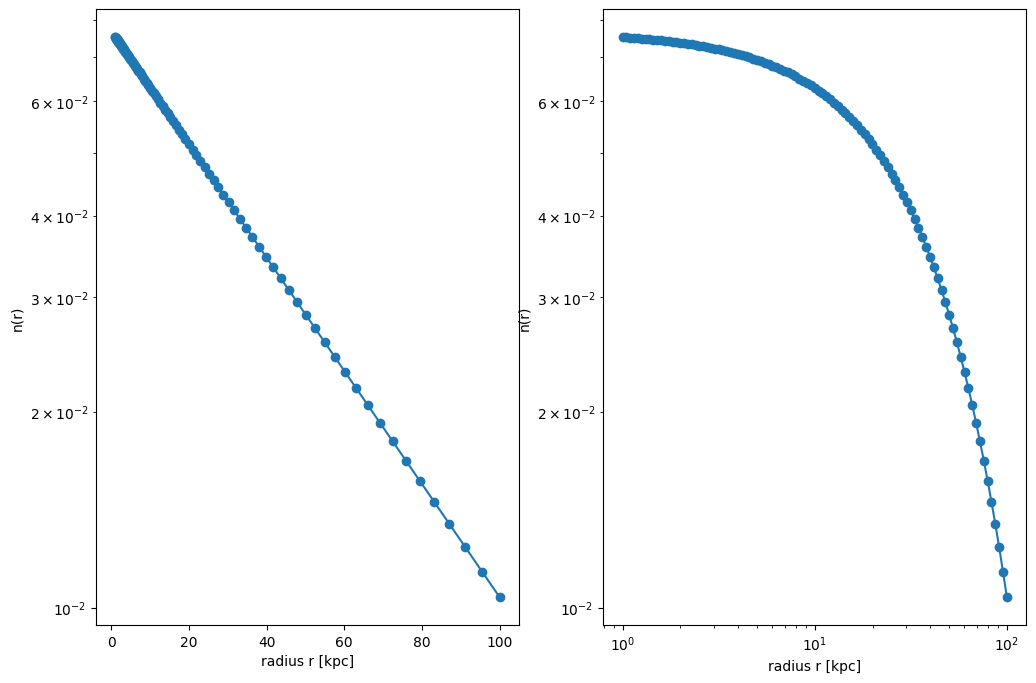

In [7]:
r_in  = 1.0         # [kpc]
r_out = 100.        # [kpc]
r_e   = 0.5*r_out
NHI_total = 1.0e22    # [cm^-2]
file_dlaw = 'dlaw_exp.ini'
#--------------------------------------------------

n0 = 1.0
rr = np.logspace(log10(r_in), log10(r_out), 101)

nn_exp = n0*exp(-rr/r_e)

# Scale to match the total H column density
# Analytic solution
n0_analytic = NHI_total / (exp(-r_in/r_e) - exp(-r_out/r_e)) / (r_e*kpc)

# Numerical integration for arbitrary functional form
NHI_integ = simps(nn_exp, rr) * kpc
n0 = NHI_total / NHI_integ
nn_exp = n0*exp(-rr/r_e)

fig = plt.figure(1,figsize=(12,8))
# plot with linear-log space
plt.subplot(1,2,1)
plt.plot(rr, nn_exp, 'o-')
plt.xlabel(r'radius r [kpc]')
plt.ylabel(r'n(r)')
plt.yscale('log')

# plot with linear-log space
plt.subplot(1,2,2)
plt.plot(rr, nn_exp, 'o-')
plt.xlabel(r'radius r [kpc]')
plt.ylabel(r'n(r)')
plt.xscale('log')
plt.yscale('log')

# Pad one more pixel outside the r_out to include full range 
# that is specified in "radius [r_in, r_out]"
# Purely numerical reason.
rr_pad = r_out * (rr[1]/rr[0])
nn_pad = n0*exp(-rr_pad/r_e)

# Output
# for ii in range(len(rr)):
    # print("continue {:8.5f} {:8.5f}".format(log10(rr[ii]*kpc), log10(nn_exp[ii])))
print(f'n_min = {nn_exp.min():.2e}')
print(f'n_max = {nn_exp.max():.2e}')







Equivalent Width = 53.95 Angstrom
Total Flux = 2.43e+30 


(1450.0, 1650.0)

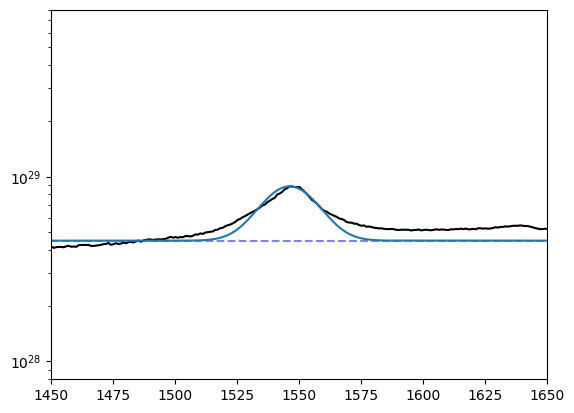

In [8]:
def Flux(Fc,F_max,lam,lam_c,sig_vel):
    del_lam = sig_vel / c_kms  * lam_c
    Flux = (F_max-Fc)*np.exp(- (lam-lam_c)**2 / del_lam**2) + Fc
    return Flux
def EW(Fc,F_max,lam_c,sig_vel):
    del_lam = sig_vel / c_kms  * lam_c
    EW =(F_max/ Fc)*np.sqrt(np.pi)*del_lam
    return EW

def Ryd_to_lam(Ryd_x):
    lambda_x = c_cms /  (Ryd_x * 13.6 /h_ev) *1e8

Lumin =44.0 # 37.0 - 44.0 + 41.5, 42.5, 43.5 and 44.5
idx_1 = 1 # 1 "" and  2 "no line transfer"
idx_2 = 2
metals = 1.0 # 0.001 - 10.0
Column_density_order = 22.0  # 18.0 - 25.0

Ryd, Fnu = QSO_SED(path = path(Lumin,idx_1,metals,Column_density_order))
nu = (Ryd * 13.6 /h_ev)
nuFnu = Fnu * nu


normalized_factor = 10**(Lumin)/nuFnu[np.where(Ryd==1)[0]] 
normalized_Fnu = Fnu*normalized_factor

Fc=4.5e28
plt.axhline(y=Fc,xmin=0,xmax=1,color='b',linestyle='--',alpha=0.5)
lambda_x = c_cms /  (Ryd * 13.6 /h_ev) *1e8
ii = np.where((lambda_x >1400) & (lambda_x <= 1700))[0]

aa = np.argmax(normalized_Fnu[ii])
F_max = normalized_Fnu[ii[aa]] 
lambda_c = lambda_x[ii[aa]]



sig_vel = 3000
flux = Flux(Fc,F_max,lambda_x,lambda_c,sig_vel)
ew = EW(Fc,F_max,lambda_c,sig_vel)

plt.plot(lambda_x,normalized_Fnu,'k-',alpha=1.0)
plt.plot(lambda_x,flux)

plt.yscale('log')

# plt.xlim(1100,1800)
plt.ylim(ymin=0.8e28,ymax=8e29)

print(f'Equivalent Width = {ew:.2f} Angstrom')
print(f'Total Flux = {ew*Fc:.2e} ') 
# plt.plot(lambda_x , normalized_nuFnu,'k-')


plt.xlim(1450,1650)
# plt.ylim(ymin=0.8e44)

In [9]:


cloudy_data_1 = CLOUDY_data(Lumin,idx_1,metals,Column_density_order)
cloudy_data_2 = CLOUDY_data(Lumin,idx_2,metals,Column_density_order)

print('--'*50)
print(f"Lya Luminosity = {cloudy_data_2[f'Lumin_Lya_{Lumin}']:.2e} [erg/s]")

print('--'*50)
print(f"C IV Luminosity = {cloudy_data_2[f'Lumin_CIV_{Lumin}']:.2e} [erg/s]")
print(f"HeII Luminosity = {cloudy_data_2[f'Lumin_HeII_{Lumin}']:.2e} [erg/s]")
print('--'*50)
print(f"C IV Column_density = {cloudy_data_2[f'Column_density_CIV_{Lumin}']:.2e} [cm-2]")
print(f"He II Column_density = {cloudy_data_2[f'Column_density_HeII_{Lumin}']:.2e} [cm-2]")
print('--'*50)

----------------------------------------------------------------------------------------------------
Lya Luminosity = 4.30e+43 [erg/s]
----------------------------------------------------------------------------------------------------
C IV Luminosity = 1.90e+42 [erg/s]
HeII Luminosity = 1.00e+42 [erg/s]
----------------------------------------------------------------------------------------------------
C IV Column_density = 3.59e+17 [cm-2]
He II Column_density = 2.50e+20 [cm-2]
----------------------------------------------------------------------------------------------------



     **Luminosity, Emissivity and number density profile**

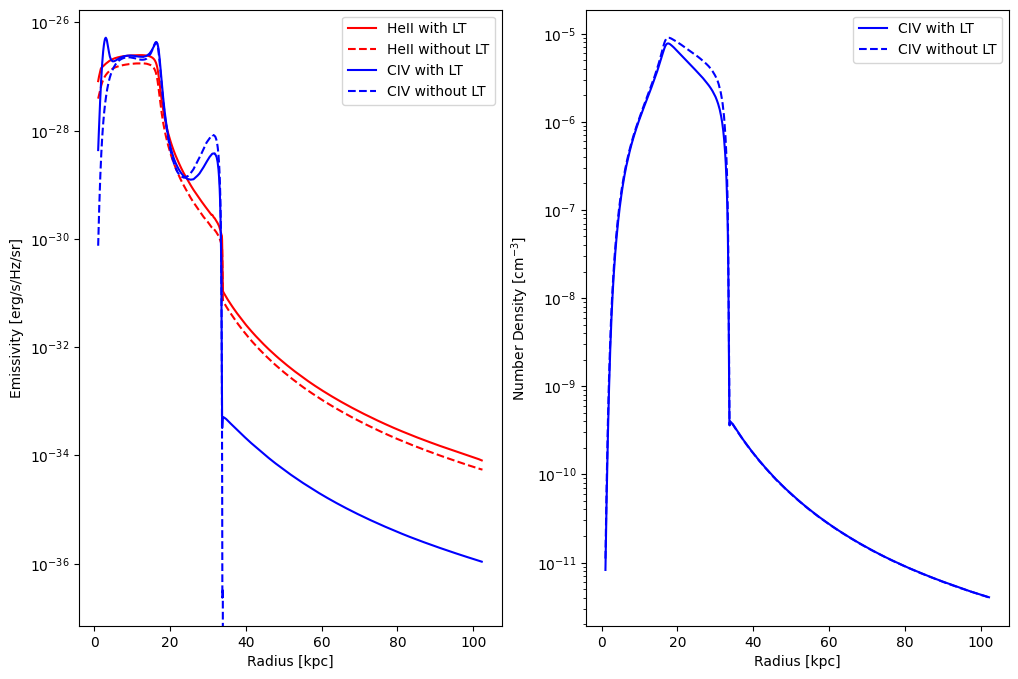

In [10]:
z = 0
red_shift_f = (1+z)**4
sr_to_arc = (180*3600 / np.pi)**2
fac = red_shift_f / sr_to_arc
fig= plt.figure(1,figsize=(12,8))
plt.subplot(1,2,1)
atom = 'HeII'
plt.plot(cloudy_data_1[f'radius_{Lumin}'],cloudy_data_1[f'emis_{atom}_{Lumin}'],'r-',label=f'{atom} with LT')
plt.plot(cloudy_data_2[f'radius_{Lumin}'],cloudy_data_2[f'emis_{atom}_{Lumin}'],'r--',label=f'{atom} without LT')
atom = 'CIV'
plt.plot(cloudy_data_1[f'radius_{Lumin}'],cloudy_data_1[f'emis_{atom}_{Lumin}'],'b-',label=f'{atom} with LT')
plt.plot(cloudy_data_2[f'radius_{Lumin}'],cloudy_data_2[f'emis_{atom}_{Lumin}'],'b--',label=f'{atom} without LT')

plt.xlabel('Radius [kpc]')
plt.ylabel('Emissivity [erg/s/Hz/sr]')
plt.yscale('log')
plt.legend()

plt.subplot(1,2,2)
# atom = 'HeII'
# plt.plot(cloudy_data_1[f'radius_{Lumin}'],cloudy_data_1[f'nden_{atom}_{Lumin}'],'r-',label=f'{atom} with LT')
# plt.plot(cloudy_data_2[f'radius_{Lumin}'],cloudy_data_2[f'nden_{atom}_{Lumin}'],'r--',label=f'{atom} without LT')
atom = 'CIV'
plt.plot(cloudy_data_1[f'radius_{Lumin}'],cloudy_data_1[f'nden_{atom}_{Lumin}'],'b-',label=f'{atom} with LT')
plt.plot(cloudy_data_2[f'radius_{Lumin}'],cloudy_data_2[f'nden_{atom}_{Lumin}'],'b--',label=f'{atom} without LT')
plt.xlabel('Radius [kpc]')
plt.ylabel('Number Density [cm$^{-3}$]')
plt.yscale('log')
plt.legend()


# print(f"HeI Luminosity = {cloudy_data_1[f'Lumin_HeI_{Lumin}_{idx}']:.4e} [erg/s]")

# f'Column_density_CIV_{Lumin}_{idx}'




     **Surface Brightness profile**

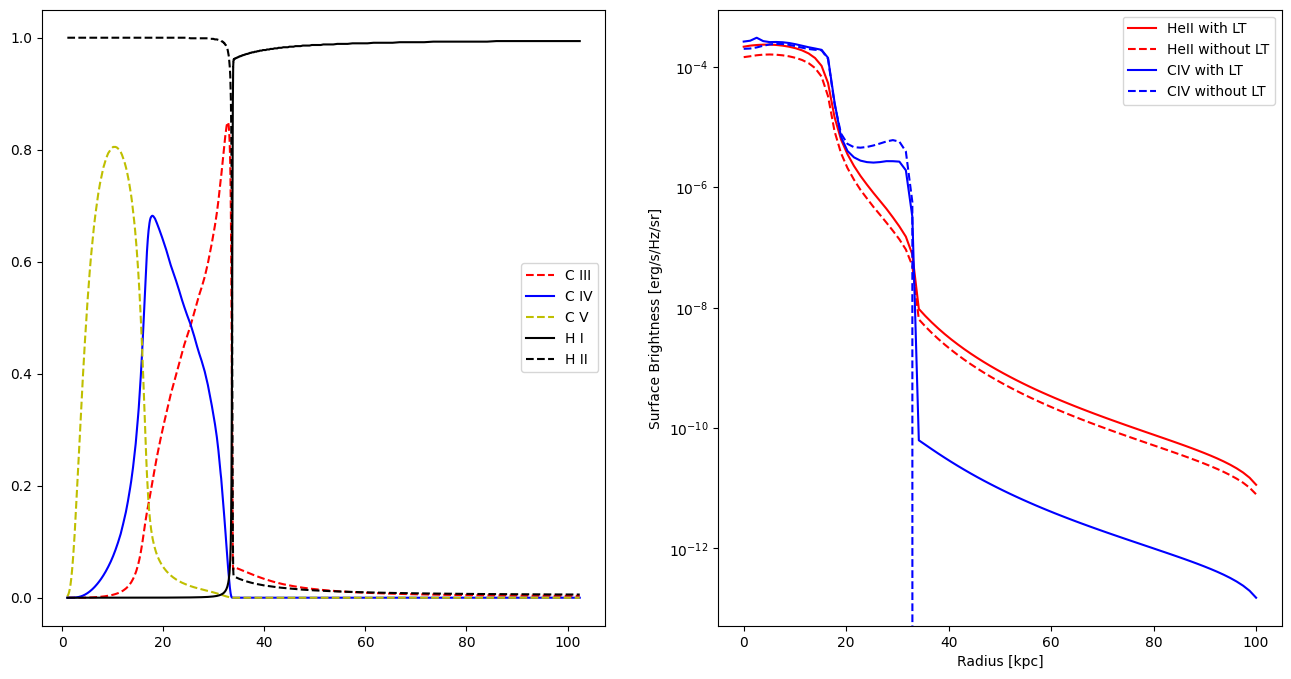

In [11]:
z = 0
red_shift_f = (1+z)**4
sr_to_arc = (180*3600 / np.pi)**2
fac = red_shift_f / sr_to_arc
fig= plt.figure(1,figsize=(16,8))

plt.subplot(121)
plt.plot(cloudy_data_2[f'radius_{Lumin}'],cloudy_data_2[f'frac_CIII_{Lumin}'],'r--',label=f'C III')
plt.plot(cloudy_data_2[f'radius_{Lumin}'],cloudy_data_2[f'frac_CIV_{Lumin}'],'b-',label=f'C IV')
plt.plot(cloudy_data_2[f'radius_{Lumin}'],cloudy_data_2[f'frac_CV_{Lumin}'],'y--',label=f'C V')

plt.plot(cloudy_data_2[f'radius_{Lumin}'],cloudy_data_2[f'frac_HI_{Lumin}'],'k-',label=f'H I')
plt.plot(cloudy_data_2[f'radius_{Lumin}'],cloudy_data_2[f'frac_HII_{Lumin}'],'k--',label=f'H II')
plt.legend()
# plt.xlim(0,20)

plt.subplot(122)
atom = 'HeII'
plt.plot(cloudy_data_1[f'radius_p_{Lumin}'],cloudy_data_1[f'SB_{atom}_{Lumin}'],'r-',label=f'{atom} with LT')
plt.plot(cloudy_data_2[f'radius_p_{Lumin}'],cloudy_data_2[f'SB_{atom}_{Lumin}'],'r--',label=f'{atom} without LT')
atom = 'CIV'
plt.plot(cloudy_data_1[f'radius_p_{Lumin}'],cloudy_data_1[f'SB_{atom}_{Lumin}'],'b-',label=f'{atom} with LT')
plt.plot(cloudy_data_2[f'radius_p_{Lumin}'],cloudy_data_2[f'SB_{atom}_{Lumin}'],'b--',label=f'{atom} without LT')
plt.xlabel('Radius [kpc]')
plt.ylabel('Surface Brightness [erg/s/Hz/sr]')
plt.yscale('log')
plt.legend()